In [ ]:
from pydantic import BaseModel, Field
from typing import List, Optional

# ---------------- TEACHER ----------------
class TeacherQAItem(BaseModel):
    id: int = Field(..., description="Unique ID of the question")
    question_no: Optional[str] = Field(None, description="Original question number")
    question: str = Field(..., description="The question text")
    answer: str = Field(..., description="Reference answer (ground truth)")
    marks: Optional[int] = Field(None, description="Maximum marks")

class TeacherQADocument(BaseModel):
    questions: List[TeacherQAItem]


# ---------------- STUDENT ----------------
class StudentQAItem(BaseModel):
    id: int = Field(..., description="Must match teacher question ID")
    question_no: Optional[str] = Field(None, description="Question number")
    question: Optional[str] = Field(None, description="Optional question text")
    answer: str = Field(..., description="Student answer")

class StudentQADocument(BaseModel):
    questions: List[StudentQAItem]

In [ ]:
from llama_cloud import LlamaCloud
import time

client = LlamaCloud(api_key="llx-rjMKvxYuKbpyqJXO2aVvayOKH7SETUj6RliBvN8ewNOrfxIJ")

# Upload teacher file
teacher_file = client.files.create(
    file="answer.txt",
    purpose="extract"
)

# Start extraction
teacher_job = client.extract.create(
    file_input=teacher_file.id,
    configuration={
        "data_schema": TeacherQADocument.model_json_schema(),
        "extraction_target": "per_doc",
        "tier": "agentic",
    },
)

# Polling
while teacher_job.status not in ("COMPLETED", "FAILED", "CANCELLED"):
    time.sleep(2)
    teacher_job = client.extract.get(teacher_job.id)

teacher_data = teacher_job.extract_result
print("Teacher Data:", teacher_data)

Teacher Data: {'questions': [{'id': 1, 'marks': None, 'answer': 'Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think, reason, and learn like human. It encompasses a wide range of technologies, including machine learning, natural language processing, and computer vision. AI systems can perform tasks such as decision-making, problem-solving, speech recognition, and language translation. In modern applications, AI is used in healthcare, finance, autonomous vehicles, and recommendation systems.', 'question': 'What is Artificial Intelligence?', 'question_no': 'Q1'}, {'id': 2, 'marks': None, 'answer': 'Machine Learning (ML) is a subset of Artificial Intelligence that focuses on building systems that can learn from data and improve their performance over time without being explicitly programmed. ML algorithms identify patterns in data and make predictions or decisions based on those patterns. There are three main types of machin

In [7]:
from llama_cloud import LlamaCloud
import time

client = LlamaCloud(api_key="llx-rjMKvxYuKbpyqJXO2aVvayOKH7SETUj6RliBvN8ewNOrfxIJ")

# Upload teacher file
student_file = client.files.create(
    file="answer.txt",
    purpose="extract"
)

# Start extraction
student_job = client.extract.create(
    file_input=student_file.id,
    configuration={
        "data_schema": StudentQADocument.model_json_schema(),
        "extraction_target": "per_doc",
        "tier": "agentic",
    },
)

# Polling
while student_job.status not in ("COMPLETED", "FAILED", "CANCELLED"):
    time.sleep(2)
    student_job = client.extract.get(student_job.id)

student_data = student_job.extract_result
print("Student Data:", student_data)

Student Data: {'questions': [{'id': 1, 'answer': 'Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think, reason, and learn like humans.\nIt encompasses a wide range of technologies, including machine learning, natural language processing, and computer vision.', 'question': None, 'question_no': 'Q1'}, {'id': 2, 'answer': 'Machine Learning (ML) is a subset of Artificial Intelligence that focuses on building systems that can learn from data and improve their performance over time without being explicitly programmed.\nML algorithms identify patterns in data and make predictions or decisions based on those patterns.', 'question': None, 'question_no': 'Q2'}, {'id': 3, 'answer': 'Deep Learning is a specialized subset of machine learning that uses artificial neural networks with multiple layers (hence "deep") to model complex patterns in data.\nThese neural networks are inspired by the structure of the human brain.', 'question': No

In [3]:
from pydantic import BaseModel, Field
from typing import List, Optional


# ── Teacher extraction ────────────────────────────────────────────────────────

class TeacherQAItem(BaseModel):
    id: int = Field(..., description="Unique sequential ID starting from 1")
    question_no: Optional[str] = Field(None, description="Original question number e.g. Q1")
    question: str = Field(..., description="Full question text")
    answer: str = Field(..., description="Complete reference answer")
    marks: Optional[int] = Field(None, description="Maximum marks allocated")
    rubric: Optional[str] = Field(None, description="Evaluation criteria or key points")


class TeacherQADocument(BaseModel):
    questions: List[TeacherQAItem]


# ── Student extraction ────────────────────────────────────────────────────────

class StudentQAItem(BaseModel):
    id: int = Field(..., description="Must match the teacher question ID")
    question_no: Optional[str] = Field(None, description="Question number e.g. Q1")
    question: Optional[str] = Field(None, description="Question text if restated by student")
    answer: str = Field(..., description="Student's full answer")


class StudentQADocument(BaseModel):
    questions: List[StudentQAItem]


# ── Per-question evaluation ───────────────────────────────────────────────────

class QuestionTags(BaseModel):
    logic: float = Field(..., ge=0, le=10, description="Logical reasoning score 0-10")
    clarity: float = Field(..., ge=0, le=10, description="Clarity of writing score 0-10")
    completeness_pct: float = Field(..., ge=0, le=100, description="Percentage of key points covered")


class QuestionEvalOutput(BaseModel):
    """Structured evaluation output for a single question."""
    awarded_score: float = Field(..., description="Marks awarded, between 0 and max_score")
    compliment: str = Field(..., description="1-2 sentences on what the student did well")
    deduction: Optional[str] = Field(None, description="1-2 sentences on what was missing or wrong, null if perfect")
    tags: QuestionTags


class QuestionResult(BaseModel):
    num: str
    question: str
    awarded_score: float
    max_score: float
    compliment: str
    deduction: Optional[str]
    tags: QuestionTags


# ── Overall evaluation ────────────────────────────────────────────────────────

class OverallEvalOutput(BaseModel):
    """Holistic assessment summary produced by the overall evaluator node."""
    summary: str = Field(..., description="2 sentence overall summary of student performance")
    early_insight: str = Field(..., description="1 sentence notable pattern — key strength or weakness")
    ai_confidence_pct: int = Field(..., ge=0, le=100, description="Confidence in this evaluation 0-100")
    plagiarism_pct: float = Field(..., ge=0, le=100, description="Estimated plagiarism likelihood 0-100, 0 means clean")


# ── Final JSONB shape ─────────────────────────────────────────────────────────

class AIResults(BaseModel):
    summary: str
    early_insight: str
    questions: List[QuestionResult]


# ── LangGraph state ───────────────────────────────────────────────────────────

class AssessmentState(BaseModel):
    model_config = {"arbitrary_types_allowed": True}

    # ── Identity
    assessment_id: str

    # ── File input (bytes from frontend upload)
    teacher_data: Optional[bytes] = None
    teacher_data_filename: Optional[str] = None
    student_data: Optional[bytes] = None
    student_data_filename: Optional[str] = None

    # ── Plain text fallback (when no file uploaded)
    teacher_text_data: Optional[str] = None
    student_text_data: Optional[str] = None

    # ── Intermediate
    teacher_doc: Optional[TeacherQADocument] = None
    student_doc: Optional[StudentQADocument] = None
    question_results: List[QuestionResult] = []

    # ── Final output
    ai_results: Optional[AIResults] = None
    overall_score: Optional[int] = None
    ai_confidence_pct: Optional[int] = None
    similarity_score: Optional[float] = None
    plagiarism_pct: Optional[float] = None

    # ── Error propagation
    error: Optional[str] = None

In [4]:
import os
import json
import time
import tempfile
import asyncio
from typing import Optional

from llama_cloud import LlamaCloud
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer


from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file
# ── Clients ───────────────────────────────────────────────────────────────────

# Base LLM — reasoning_format="hidden" keeps chain-of-thought internal
# so structured output tool-calling is never polluted by <think> tokens
llm = ChatGroq(
    model="llama-3.3-70b-versatile"  
)

embedder = SentenceTransformer("all-MiniLM-L6-v2")
llama    = LlamaCloud(api_key=os.environ["LLAMA_CLOUD_API_KEY"])


# ── Structured output LLM variants ───────────────────────────────────────────
# Each is a separate chain — avoids re-creating on every call

llm_teacher_extractor  = llm.with_structured_output(TeacherQADocument)
llm_student_extractor  = llm.with_structured_output(StudentQADocument)
llm_question_evaluator = llm.with_structured_output(QuestionEvalOutput)
llm_overall_evaluator  = llm.with_structured_output(OverallEvalOutput)


# ── Helper: LlamaCloud extraction (file path → Pydantic model) ───────────────

def _llamacloud_extract(
    data: Optional[bytes],
    filename: Optional[str],
    text_fallback: Optional[str],
    schema: dict,
) -> dict:
    """
    Uploads a file (or a text wrapped as .txt) to LlamaCloud, runs agentic
    extraction against the given JSON schema, polls until done, returns the
    raw result dict.
    """
    if data and filename:
        file_bytes   = data
        upload_name  = filename
    else:
        file_bytes   = text_fallback.encode("utf-8")
        upload_name  = "input.txt"

    suffix = os.path.splitext(upload_name)[-1] or ".txt"

    with tempfile.NamedTemporaryFile(suffix=suffix, delete=False) as tmp:
        tmp.write(file_bytes)
        tmp_path = tmp.name

    try:
        uploaded = llama.files.create(file=tmp_path, purpose="extract")

        job = llama.extract.create(
            file_input=uploaded.id,
            configuration={
                "data_schema":       schema,
                "extraction_target": "per_doc",
                "tier":              "agentic",
            },
        )

        while job.status not in ("COMPLETED", "FAILED", "CANCELLED"):
            time.sleep(2)
            job = llama.extract.get(job.id)

        if job.status != "COMPLETED":
            raise RuntimeError(
                f"LlamaCloud extraction ended with status '{job.status}' "
                f"(job_id={job.id})"
            )

        return job.extract_result

    finally:
        os.unlink(tmp_path)


# ── NODE 1: Extract teacher Q&A ───────────────────────────────────────────────

async def node_extract_teacher(state: AssessmentState) -> AssessmentState:
    try:
        if state.teacher_data or state.teacher_text_data:
            # LlamaCloud handles file/image/pdf/docx/txt natively
            result = await asyncio.to_thread(
                _llamacloud_extract,
                state.teacher_data,
                state.teacher_data_filename,
                state.teacher_text_data,
                TeacherQADocument.model_json_schema(),
            )
            state.teacher_doc = TeacherQADocument(**result)
        else:
            raise ValueError("No teacher data provided — supply teacher_data (bytes) or teacher_text_data.")

    except Exception as e:
        state.error = f"Teacher extraction failed: {e}"

    return state


# ── NODE 2: Extract student answers ──────────────────────────────────────────

async def node_extract_student(state: AssessmentState) -> AssessmentState:
    try:
        if state.student_data or state.student_text_data:
            result = await asyncio.to_thread(
                _llamacloud_extract,
                state.student_data,
                state.student_data_filename,
                state.student_text_data,
                StudentQADocument.model_json_schema(),
            )
            raw_doc = StudentQADocument(**result)
        else:
            raise ValueError("No student data provided — supply student_data (bytes) or student_text_data.")

        # ── Align student IDs to teacher IDs via structured LLM ──────────────
        # LlamaCloud extracts answers correctly but may number them independently.
        # We re-align with a structured output call so IDs always match teacher.
        teacher_structure = json.dumps(
            [
                {"id": q.id, "question_no": q.question_no, "question": q.question}
                for q in state.teacher_doc.questions
            ],
            indent=2,
        )

        alignment_prompt = [
            SystemMessage(content=(
                "You are a document alignment assistant. "
                "Re-map the student answers to the correct teacher question IDs. "
                "Match by question number or content similarity. "
                "If a student skipped a question, omit it. "
                "Return the corrected student document."
            )),
            HumanMessage(content=(
                f"TEACHER QUESTIONS (for ID reference):\n{teacher_structure}\n\n"
                f"EXTRACTED STUDENT ANSWERS (may have wrong IDs):\n"
                f"{raw_doc.model_dump_json(indent=2)}"
            )),
        ]

        state.student_doc = await llm_student_extractor.ainvoke(alignment_prompt)

    except Exception as e:
        state.error = f"Student extraction failed: {e}"

    return state


# ── NODE 3: Evaluate each question concurrently ───────────────────────────────

async def node_evaluate_questions(state: AssessmentState) -> AssessmentState:
    try:
        teacher_map = {q.id: q for q in state.teacher_doc.questions}
        student_map = {q.id: q for q in state.student_doc.questions}

        async def evaluate_one(teacher_q, student_q) -> QuestionResult:
            max_marks = teacher_q.marks or 10

            messages = [
                SystemMessage(content=(
                    "You are a strict but fair academic evaluator. "
                    "Evaluate the student's answer against the reference answer and rubric. "
                    f"The maximum marks for this question is {max_marks}. "
                    f"Rubric: {teacher_q.rubric or 'No rubric provided — use the reference answer as the guide.'} "
                    "Deduct proportionally for missing key points. "
                    "awarded_score must be between 0 and max_marks."
                )),
                HumanMessage(content=(
                    f"QUESTION: {teacher_q.question}\n\n"
                    f"REFERENCE ANSWER:\n{teacher_q.answer}\n\n"
                    f"STUDENT ANSWER:\n"
                    f"{student_q.answer if student_q else '[No answer provided — award 0 marks]'}\n\n"
                    f"MAX MARKS: {max_marks}"
                )),
            ]

            eval_output: QuestionEvalOutput = await llm_question_evaluator.ainvoke(messages)

            # Clamp awarded_score to valid range (model may occasionally exceed bounds)
            awarded = max(0.0, min(float(eval_output.awarded_score), float(max_marks)))

            return QuestionResult(
                num=teacher_q.question_no or str(teacher_q.id).zfill(2),
                question=teacher_q.question,
                awarded_score=awarded,
                max_score=float(max_marks),
                compliment=eval_output.compliment,
                deduction=eval_output.deduction,
                tags=eval_output.tags,
            )

        tasks = [
            evaluate_one(teacher_map[tid], student_map.get(tid))
            for tid in teacher_map
        ]

        state.question_results = list(await asyncio.gather(*tasks))

    except Exception as e:
        state.error = f"Question evaluation failed: {e}"

    return state


# ── NODE 4: Compute semantic similarity ───────────────────────────────────────

async def node_compute_similarity(state: AssessmentState) -> AssessmentState:
    try:
        teacher_text = " ".join(q.answer for q in state.teacher_doc.questions)
        student_text = " ".join(q.answer for q in state.student_doc.questions)

        def _compute() -> float:
            t_emb = embedder.encode([teacher_text])
            s_emb = embedder.encode([student_text])
            return round(float(cosine_similarity(t_emb, s_emb)[0][0]) * 100, 2)

        state.similarity_score = await asyncio.to_thread(_compute)

    except Exception as e:
        state.error = f"Similarity computation failed: {e}"

    return state


# ── NODE 5: Overall evaluator ─────────────────────────────────────────────────

async def node_overall_evaluator(state: AssessmentState) -> AssessmentState:
    try:
        total_awarded = sum(q.awarded_score for q in state.question_results)
        total_max     = sum(q.max_score     for q in state.question_results)
        overall_score = round((total_awarded / total_max) * 100) if total_max else 0

        results_summary = json.dumps(
            [r.model_dump() for r in state.question_results],
            indent=2,
        )

        messages = [
            SystemMessage(content=(
                "You are a senior academic reviewer. "
                "Analyse the per-question evaluation results holistically. "
                "ai_confidence_pct reflects how consistent and clear the student answers were. "
                "plagiarism_pct is an estimate based on writing style uniformity — 0 means clean, "
                "high values mean suspiciously polished or copied text."
            )),
            HumanMessage(content=(
                f"PER-QUESTION RESULTS:\n{results_summary}\n\n"
                f"OVERALL SCORE: {overall_score}/100"
            )),
        ]

        meta: OverallEvalOutput = await llm_overall_evaluator.ainvoke(messages)

        state.overall_score     = overall_score
        state.ai_confidence_pct = max(0, min(100, meta.ai_confidence_pct))
        state.plagiarism_pct    = round(max(0.0, min(100.0, meta.plagiarism_pct)), 2)

        state.ai_results = AIResults(
            summary=meta.summary,
            early_insight=meta.early_insight,
            questions=list(state.question_results),
        )

    except Exception as e:
        state.error = f"Overall evaluation failed: {e}"

    return state


# ── NODE 6: Persist to Supabase ───────────────────────────────────────────────

async def node_persist(state: AssessmentState) -> AssessmentState:
    try:
        from supabase import create_client

        supabase = create_client(
            os.environ["SUPABASE_URL"],
            os.environ["SUPABASE_SERVICE_ROLE_KEY"],
        )

        BUCKET = "assessments"

        teacher_data_url: Optional[str] = None
        student_data_url: Optional[str] = None

        # ── Upload files to Supabase Storage ──────────────────────────────────
        if state.teacher_data and state.teacher_data_filename:
            path = f"{state.assessment_id}/teacher/{state.teacher_data_filename}"
            await asyncio.to_thread(
                lambda: supabase.storage.from_(BUCKET).upload(
                    path, state.teacher_data, {"upsert": "true"}
                )
            )
            teacher_data_url = supabase.storage.from_(BUCKET).get_public_url(path)

        if state.student_data and state.student_data_filename:
            path = f"{state.assessment_id}/student/{state.student_data_filename}"
            await asyncio.to_thread(
                lambda: supabase.storage.from_(BUCKET).upload(
                    path, state.student_data, {"upsert": "true"}
                )
            )
            student_data_url = supabase.storage.from_(BUCKET).get_public_url(path)

        # ── Build DB payload ──────────────────────────────────────────────────
        payload = {
            "status":            "completed",
            "ai_results":        state.ai_results.model_dump(),
            "overall_score":     state.overall_score,
            "ai_confidence_pct": state.ai_confidence_pct,
            "similarity_score":  state.similarity_score,
            "plagiarism_pct":    state.plagiarism_pct,
            "completed_at":      "now()",
        }

        if teacher_data_url:
            payload["teacher_data_url"] = teacher_data_url
        if student_data_url:
            payload["student_data_url"] = student_data_url
        if state.teacher_text_data:
            payload["teacher_text_data"] = state.teacher_text_data
        if state.student_text_data:
            payload["student_text_data"] = state.student_text_data

        await asyncio.to_thread(
            lambda: supabase.table("assessments")
                .update(payload)
                .eq("id", state.assessment_id)
                .execute()
        )

    except Exception as e:
        state.error = f"Persist failed: {e}"

    return state


# ── Error handler ─────────────────────────────────────────────────────────────

async def node_handle_error(state: AssessmentState) -> AssessmentState:
    try:
        from supabase import create_client

        supabase = create_client(
            os.environ["SUPABASE_URL"],
            os.environ["SUPABASE_SERVICE_ROLE_KEY"],
        )

        await asyncio.to_thread(
            lambda: supabase.table("assessments")
                .update({"status": "failed"})
                .eq("id", state.assessment_id)
                .execute()
        )
    except Exception:
        pass  # Best-effort — original error is already in state.error

    return state

c:\Users\adeel\Desktop\Paper_checking_Saas\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1920.78it/s]


In [5]:
from langgraph.graph import StateGraph, END
from models import AssessmentState

# Ordered pipeline — each step feeds the next
PIPELINE = [
    ("extract_teacher",    "extract_student"),
    ("extract_student",    "evaluate_questions"),
    ("evaluate_questions", "compute_similarity"),
    ("compute_similarity", "overall_evaluator"),
    ("overall_evaluator",  "persist"),
]


def _route(next_node: str):
    """Returns a router function that either advances or diverts to handle_error."""
    def router(state: AssessmentState) -> str:
        return "handle_error" if state.error else next_node
    router.__name__ = f"route_to_{next_node}"
    return router


def build_graph() -> StateGraph:
    graph = StateGraph(AssessmentState)

    # ── Register nodes ────────────────────────────────────────────────────────
    graph.add_node("extract_teacher",    node_extract_teacher)
    graph.add_node("extract_student",    node_extract_student)
    graph.add_node("evaluate_questions", node_evaluate_questions)
    graph.add_node("compute_similarity", node_compute_similarity)
    graph.add_node("overall_evaluator",  node_overall_evaluator)
    graph.add_node("persist",            node_persist)
    graph.add_node("handle_error",       node_handle_error)

    graph.set_entry_point("extract_teacher")

    # ── Happy path with error short-circuit on every step ────────────────────
    for current, next_node in PIPELINE:
        graph.add_conditional_edges(
            current,
            _route(next_node),
            {next_node: next_node, "handle_error": "handle_error"},
        )

    # persist is the last real node
    graph.add_conditional_edges(
        "persist",
        lambda state: "handle_error" if state.error else END,
        {"handle_error": "handle_error", END: END},
    )

    graph.add_edge("handle_error", END)

    return graph.compile()


assessment_graph = build_graph()

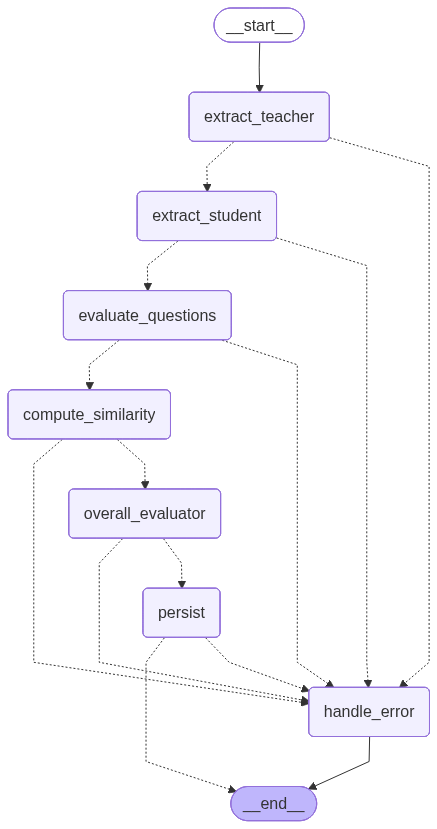

In [5]:
assessment_graph

In [8]:
import asyncio
import os
from typing import Optional

async def run_assessment(
    assessment_id: str,
    teacher_data: bytes,
    teacher_data_filename: str,
    student_data: bytes,
    student_data_filename: str,
) -> None:
    initial_state = AssessmentState(
        assessment_id=assessment_id,
        teacher_data=teacher_data,
        teacher_data_filename=teacher_data_filename,
        student_data=student_data,
        student_data_filename=student_data_filename,
    )

    try:
        await assessment_graph.ainvoke(initial_state)
    except Exception as e:
        initial_state.error = str(e)
        await node_handle_error(initial_state)
        raise


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    teacher_path = "image.png"
    student_path = "answer.txt"
    test_id      = "test-assessment-001"

    with open(teacher_path, "rb") as f:
        t_bytes = f.read()
    with open(student_path, "rb") as f:
        s_bytes = f.read()

    run_assessment(
        assessment_id=test_id,
        teacher_data=t_bytes,
        teacher_data_filename=os.path.basename(teacher_path),
        student_data=s_bytes,
        student_data_filename=os.path.basename(student_path),
    )

C:\Users\adeel\AppData\Local\Temp\ipykernel_20336\3983102262.py:39: RuntimeWarning: coroutine 'run_assessment' was never awaited
  run_assessment(


In [ ]:
from pydantic import BaseModel, Field
from typing import List, Optional


class TeacherQAItem(BaseModel):
    id: int
    question_no: Optional[str] = None
    question: str
    answer: str
    marks: Optional[int] = None
    rubric: Optional[str] = None


class TeacherQADocument(BaseModel):
    questions: List[TeacherQAItem]


class StudentQAItem(BaseModel):
    id: int
    question_no: Optional[str] = None
    question: Optional[str] = None
    answer: str


class StudentQADocument(BaseModel):
    questions: List[StudentQAItem]


class QuestionTags(BaseModel):
    logic: float = Field(..., ge=0, le=10)
    clarity: float = Field(..., ge=0, le=10)
    completeness_pct: float = Field(..., ge=0, le=100)


class QuestionEvalOutput(BaseModel):
    awarded_score: float
    compliment: str
    deduction: Optional[str] = None
    tags: QuestionTags


class QuestionResult(BaseModel):
    num: str
    question: str
    awarded_score: float
    max_score: float
    compliment: str
    deduction: Optional[str]
    tags: QuestionTags


class OverallEvalOutput(BaseModel):
    summary: str
    early_insight: str
    ai_confidence_pct: int = Field(..., ge=0, le=100)
    plagiarism_pct: float = Field(..., ge=0, le=100)


class AIResults(BaseModel):
    summary: str
    early_insight: str
    questions: List[QuestionResult]


class AssessmentState(BaseModel):
    model_config = {"arbitrary_types_allowed": True}
    assessment_id: str

    teacher_text_data: Optional[str] = None
    student_text_data: Optional[str] = None

    teacher_doc: Optional[TeacherQADocument] = None
    student_doc: Optional[StudentQADocument] = None
    question_results: List[QuestionResult] = []

    ai_results: Optional[AIResults] = None
    overall_score: Optional[int] = None
    ai_confidence_pct: Optional[int] = None
    similarity_score: Optional[float] = None
    plagiarism_pct: Optional[float] = None

In [10]:
import json
import asyncio

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

from models import (
    AssessmentState,
    TeacherQADocument,
    StudentQADocument,
    QuestionEvalOutput,
    OverallEvalOutput,
    QuestionResult,
    AIResults,
)

from dotenv import load_dotenv
load_dotenv()

# ── LLM setup ─────────────────────────────────────────────────────────────────

llm = ChatGroq(model="llama-3.3-70b-versatile")

llm_teacher_extractor  = llm.with_structured_output(TeacherQADocument)
llm_student_extractor  = llm.with_structured_output(StudentQADocument)
llm_question_evaluator = llm.with_structured_output(QuestionEvalOutput)
llm_overall_evaluator  = llm.with_structured_output(OverallEvalOutput)

embedder = SentenceTransformer("all-MiniLM-L6-v2")


# ── NODE 1: Extract teacher Q&A ───────────────────────────────────────────────

async def node_extract_teacher(state: AssessmentState) -> AssessmentState:
    print("\n[NODE 1] Extracting teacher Q&A...")

    if not state.teacher_text_data:
        raise ValueError("teacher_text_data is empty — check teacher.txt")

    print(f"  Teacher text preview: {state.teacher_text_data[:200]}...")

    messages = [
        SystemMessage(content=(
            "You are a document parser. Extract all questions, reference answers, "
            "marks, and rubric from the teacher's document. Assign sequential IDs starting from 1."
        )),
        HumanMessage(content=state.teacher_text_data),
    ]

    state.teacher_doc = await llm_teacher_extractor.ainvoke(messages)

    print(f"  ✓ Extracted {len(state.teacher_doc.questions)} teacher questions")
    for q in state.teacher_doc.questions:
        print(f"    [{q.id}] {q.question_no or 'Q?'} | marks={q.marks} | {q.question[:60]}...")

    return state


# ── NODE 2: Extract student answers ──────────────────────────────────────────

async def node_extract_student(state: AssessmentState) -> AssessmentState:
    print("\n[NODE 2] Extracting student answers...")

    if not state.student_text_data:
        raise ValueError("student_text_data is empty — check student.txt")

    print(f"  Student text preview: {state.student_text_data[:200]}...")

    # Step 1: raw extraction
    messages = [
        SystemMessage(content=(
            "You are a document parser. Extract all student answers from the document. "
            "Assign IDs based on question numbers you find."
        )),
        HumanMessage(content=state.student_text_data),
    ]

    raw_doc = await llm_student_extractor.ainvoke(messages)
    print(f"  Raw extraction: {len(raw_doc.questions)} answers found")

    # Step 2: align IDs to teacher
    teacher_structure = json.dumps(
        [{"id": q.id, "question_no": q.question_no, "question": q.question}
         for q in state.teacher_doc.questions],
        indent=2,
    )

    alignment_messages = [
        SystemMessage(content=(
            "Re-map the student answers to match the correct teacher question IDs. "
            "Match by question number or content. If a question was skipped, omit it."
        )),
        HumanMessage(content=(
            f"TEACHER QUESTIONS:\n{teacher_structure}\n\n"
            f"STUDENT ANSWERS (may have wrong IDs):\n{raw_doc.model_dump_json(indent=2)}"
        )),
    ]

    state.student_doc = await llm_student_extractor.ainvoke(alignment_messages)

    print(f"  ✓ Aligned {len(state.student_doc.questions)} student answers")
    for q in state.student_doc.questions:
        print(f"    [{q.id}] {q.question_no or 'Q?'} | {q.answer[:60]}...")

    return state


# ── NODE 3: Evaluate each question ────────────────────────────────────────────

async def node_evaluate_questions(state: AssessmentState) -> AssessmentState:
    print("\n[NODE 3] Evaluating questions...")

    teacher_map = {q.id: q for q in state.teacher_doc.questions}
    student_map = {q.id: q for q in state.student_doc.questions}

    print(f"  Teacher questions: {list(teacher_map.keys())}")
    print(f"  Student answers:   {list(student_map.keys())}")

    async def evaluate_one(teacher_q, student_q) -> QuestionResult:
        max_marks = teacher_q.marks or 10

        messages = [
            SystemMessage(content=(
                f"You are a strict but fair academic evaluator. "
                f"Evaluate the student's answer. Max marks = {max_marks}. "
                f"Rubric: {teacher_q.rubric or 'Use the reference answer as guide.'} "
                f"Deduct proportionally for missing points."
            )),
            HumanMessage(content=(
                f"QUESTION: {teacher_q.question}\n\n"
                f"REFERENCE ANSWER:\n{teacher_q.answer}\n\n"
                f"STUDENT ANSWER:\n"
                f"{student_q.answer if student_q else '[No answer — award 0]'}\n\n"
                f"MAX MARKS: {max_marks}"
            )),
        ]

        result: QuestionEvalOutput = await llm_question_evaluator.ainvoke(messages)
        awarded = max(0.0, min(float(result.awarded_score), float(max_marks)))

        print(f"  ✓ Q{teacher_q.id} — awarded {awarded}/{max_marks}")

        return QuestionResult(
            num=teacher_q.question_no or str(teacher_q.id).zfill(2),
            question=teacher_q.question,
            awarded_score=awarded,
            max_score=float(max_marks),
            compliment=result.compliment,
            deduction=result.deduction,
            tags=result.tags,
        )

    tasks = [
        evaluate_one(teacher_map[tid], student_map.get(tid))
        for tid in teacher_map
    ]

    state.question_results = list(await asyncio.gather(*tasks))
    print(f"  ✓ All {len(state.question_results)} questions evaluated")

    return state


# ── NODE 4: Compute similarity ────────────────────────────────────────────────

async def node_compute_similarity(state: AssessmentState) -> AssessmentState:
    print("\n[NODE 4] Computing semantic similarity...")

    teacher_text = " ".join(q.answer for q in state.teacher_doc.questions)
    student_text = " ".join(q.answer for q in state.student_doc.questions)

    def _compute() -> float:
        t_emb = embedder.encode([teacher_text])
        s_emb = embedder.encode([student_text])
        return round(float(cosine_similarity(t_emb, s_emb)[0][0]) * 100, 2)

    state.similarity_score = await asyncio.to_thread(_compute)
    print(f"  ✓ Similarity score: {state.similarity_score}%")

    return state


# ── NODE 5: Overall evaluation ────────────────────────────────────────────────

async def node_overall_evaluator(state: AssessmentState) -> AssessmentState:
    print("\n[NODE 5] Running overall evaluation...")

    total_awarded = sum(q.awarded_score for q in state.question_results)
    total_max     = sum(q.max_score     for q in state.question_results)
    overall_score = round((total_awarded / total_max) * 100) if total_max else 0

    print(f"  Total awarded: {total_awarded}/{total_max} → {overall_score}%")

    results_summary = json.dumps(
        [r.model_dump() for r in state.question_results], indent=2
    )

    messages = [
        SystemMessage(content=(
            "You are a senior academic reviewer. Analyse the per-question results holistically. "
            "ai_confidence_pct = how consistent and clear the student answers were. "
            "plagiarism_pct = suspiciously polished/copied text (0 = clean)."
        )),
        HumanMessage(content=(
            f"PER-QUESTION RESULTS:\n{results_summary}\n\n"
            f"OVERALL SCORE: {overall_score}/100"
        )),
    ]

    meta: OverallEvalOutput = await llm_overall_evaluator.ainvoke(messages)

    state.overall_score     = overall_score
    state.ai_confidence_pct = max(0, min(100, meta.ai_confidence_pct))
    state.plagiarism_pct    = round(max(0.0, min(100.0, meta.plagiarism_pct)), 2)

    state.ai_results = AIResults(
        summary=meta.summary,
        early_insight=meta.early_insight,
        questions=list(state.question_results),
    )

    print(f"  ✓ Summary: {meta.summary}")
    print(f"  ✓ Confidence: {state.ai_confidence_pct}% | Plagiarism: {state.plagiarism_pct}%")

    return state

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1803.84it/s]


In [17]:
import asyncio
import json
from langgraph.graph import StateGraph, END

from models import AssessmentState
from nodes import (
    node_extract_teacher,
    node_extract_student,
    node_evaluate_questions,
    node_compute_similarity,
    node_overall_evaluator,
)


# ── Build graph ───────────────────────────────────────────────────────────────

def build_graph():
    graph = StateGraph(AssessmentState)

    graph.add_node("extract_teacher",    node_extract_teacher)
    graph.add_node("extract_student",    node_extract_student)
    graph.add_node("evaluate_questions", node_evaluate_questions)
    graph.add_node("compute_similarity", node_compute_similarity)
    graph.add_node("overall_evaluator",  node_overall_evaluator)

    graph.set_entry_point("extract_teacher")

    graph.add_edge("extract_teacher",    "extract_student")
    graph.add_edge("extract_student",    "evaluate_questions")
    graph.add_edge("evaluate_questions", "compute_similarity")
    graph.add_edge("compute_similarity", "overall_evaluator")
    graph.add_edge("overall_evaluator",  END)

    return graph.compile()


assessment_graph = build_graph()


# ── Run ───────────────────────────────────────────────────────────────────────

async def run_assessment(assessment_id: str, teacher_path: str, student_path: str):
    print(f"\n{'='*50}")
    print(f"  Assessment ID : {assessment_id}")
    print(f"  Teacher file  : {teacher_path}")
    print(f"  Student file  : {student_path}")
    print(f"{'='*50}")

    with open(teacher_path, "r", encoding="utf-8") as f:
        teacher_text = f.read()

    with open(student_path, "r", encoding="utf-8") as f:
        student_text = f.read()

    print(f"\n[LOAD] Teacher text: {len(teacher_text)} chars")
    print(f"[LOAD] Student text: {len(student_text)} chars")

    initial_state = AssessmentState(
        assessment_id=assessment_id,
        teacher_text_data=teacher_text,
        student_text_data=student_text,
    )

    final_state: AssessmentState = await assessment_graph.ainvoke(initial_state)

    # ── Print final results ────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print("  FINAL RESULTS")
    print(f"{'='*50}")
    print(f"  Overall Score   : {final_state.overall_score}/100")
    print(f"  Similarity      : {final_state.similarity_score}%")
    print(f"  AI Confidence   : {final_state.ai_confidence_pct}%")
    print(f"  Plagiarism Est. : {final_state.plagiarism_pct}%")
    print(f"\n  Summary: {final_state.ai_results.summary}")
    print(f"  Insight: {final_state.ai_results.early_insight}")

    print(f"\n  Per-Question Breakdown:")
    for q in final_state.ai_results.questions:
        print(f"    {q.num} | {q.awarded_score}/{q.max_score} marks")
        print(f"         ✓ {q.compliment}")
        if q.deduction:
            print(f"         ✗ {q.deduction}")

    # Dump full JSON result
    print(f"\n[JSON OUTPUT]")
    print(json.dumps(final_state.ai_results.model_dump(), indent=2))

    return final_state


if __name__ == "__main__":
    await run_assessment(
        assessment_id="test-001",
        teacher_path="image.png",
        student_path="answer.txt",
    )


  Assessment ID : test-001
  Teacher file  : image.png
  Student file  : answer.txt


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte